In [98]:
!pip install wordcloud nltk scikit-learn -q
print('Packages installed.')

Packages installed.


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

COLORS = {
    'Positive':   '#27ae60',
    'Negative':   '#e74c3c',
    'Neutral':    '#2980b9',
    'Irrelevant': '#95a5a6'
}

print('All libraries imported successfully!')

All libraries imported successfully!


In [81]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):

    level = root.replace('/content/drive/MyDrive', '').count(os.sep)
    if level < 2:
        print(root)
        for f in files:
            if '.csv' in f:
                print(f'    📄 {f}')

/content/drive/MyDrive
/content/drive/MyDrive/Classroom
/content/drive/MyDrive/Kumbh
/content/drive/MyDrive/Untitled form (File responses)
/content/drive/MyDrive/appsheet
/content/drive/MyDrive/Voikes
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Marksheet
/content/drive/MyDrive/INAMIGOS
/content/drive/MyDrive/Prodigy_DS_04
    📄 twitter_validation.csv
    📄 twitter_training.csv


In [82]:
import os

FOLDER = '/content/drive/MyDrive/Prodigy_DS_04'

COLS = ['TweetID', 'Entity', 'Sentiment', 'TweetText']

df_train = pd.read_csv(os.path.join(FOLDER, 'twitter_training.csv'),   header=None, names=COLS)
df_val   = pd.read_csv(os.path.join(FOLDER, 'twitter_validation.csv'), header=None, names=COLS)

df = pd.concat([df_train, df_val], ignore_index=True)

print(f'Training rows   : {len(df_train):,}')
print(f'Validation rows : {len(df_val):,}')
print(f'Combined total  : {len(df):,}')
df.head(8)


Training rows   : 74,682
Validation rows : 1,000
Combined total  : 75,682


,TweetID,Entity,Sentiment,TweetText
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...


In [83]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted!


In [84]:
OUTPUT = FOLDER
print(f'Plots will be saved to: {OUTPUT}')


Plots will be saved to: /content/drive/MyDrive/Prodigy_DS_04


In [85]:
print('  BASIC INFO')
print(f'Shape            : {df.shape}')
print(f'Columns          : {list(df.columns)}')
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Sentiment counts:')
print(df['Sentiment'].value_counts())
print()
print('Top 10 Entities:')
print(df['Entity'].value_counts().head(10))

  BASIC INFO
Shape            : (75682, 4)
Columns          : ['TweetID', 'Entity', 'Sentiment', 'TweetText']

Missing values:
TweetID        0
Entity         0
Sentiment      0
TweetText    686
dtype: int64

Sentiment counts:
Sentiment
Negative      22808
Positive      21109
Neutral       18603
Irrelevant    13162
Name: count, dtype: int64

Top 10 Entities:
Entity
TomClancysRainbowSix         2435
LeagueOfLegends              2431
MaddenNFL                    2429
Microsoft                    2428
CallOfDuty                   2425
Verizon                      2414
ApexLegends                  2412
CallOfDutyBlackopsColdWar    2403
Facebook                     2403
WorldOfCraft                 2394
Name: count, dtype: int64


In [86]:
df.dropna(subset=['TweetText'], inplace=True)
df = df[df['TweetText'].str.strip().str.lower() != 'not available']
df.reset_index(drop=True, inplace=True)
print(f'Clean dataset size: {len(df):,} rows')

Clean dataset size: 74,996 rows


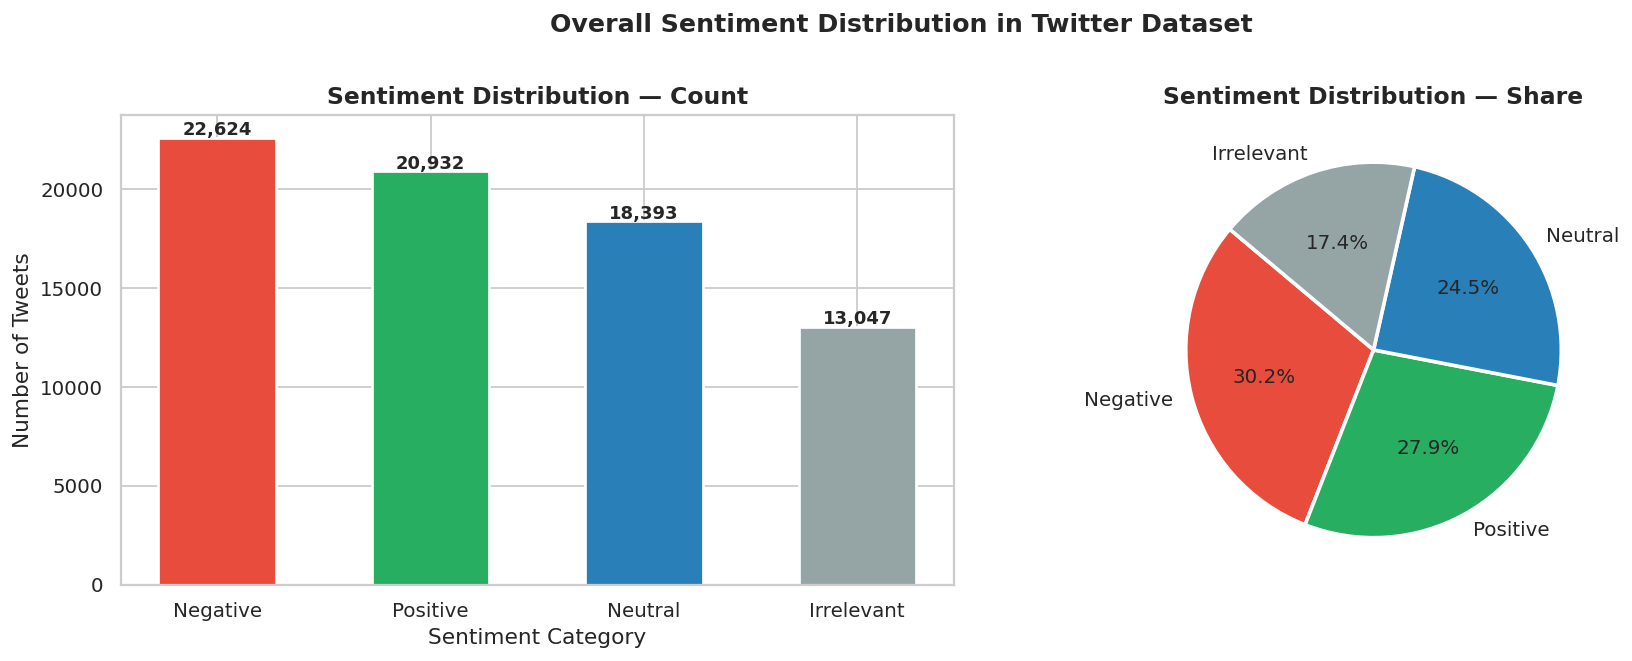

In [87]:
sent_counts = df['Sentiment'].value_counts()
bar_colors  = [COLORS.get(s, '#bdc3c7') for s in sent_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=1.5, width=0.55)
axes[0].set_title('Sentiment Distribution — Count')
axes[0].set_xlabel('Sentiment Category')
axes[0].set_ylabel('Number of Tweets')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 120,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontweight='bold', fontsize=10)

pie_colors = [COLORS.get(s, '#bdc3c7') for s in sent_counts.index]
axes[1].pie(sent_counts.values, labels=sent_counts.index,
            autopct='%1.1f%%', colors=pie_colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Distribution — Share')

plt.suptitle('Overall Sentiment Distribution in Twitter Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'sentiment_distribution.png'), bbox_inches='tight')
plt.show()

In [88]:
STOP = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [w for w in text.split() if w not in STOP and len(w) > 2]
    return " ".join(tokens)

print("Cleaning tweets...")
df["CleanText"] = df["TweetText"].astype(str).apply(clean_text)
print(f"Done! Sample:")
df[["TweetText", "CleanText", "Sentiment"]].head(4)


Cleaning tweets...
Done! Sample:


,TweetText,CleanText,Sentiment
0,im getting on borderlands and i will murder yo...,getting borderlands murder,Positive
1,I am coming to the borders and I will kill you...,coming borders kill,Positive
2,im getting on borderlands and i will kill you ...,getting borderlands kill,Positive
3,im coming on borderlands and i will murder you...,coming borderlands murder,Positive


In [89]:
sia = SentimentIntensityAnalyzer()

print("Scoring sentiments with VADER...")

scores = [sia.polarity_scores(str(t)) for t in df["TweetText"]]

df["v_neg"]      = [s["neg"]      for s in scores]
df["v_neu"]      = [s["neu"]      for s in scores]
df["v_pos"]      = [s["pos"]      for s in scores]
df["v_compound"] = [s["compound"] for s in scores]

def vader_label(c):
    if c >= 0.05:  return "Positive"
    if c <= -0.05: return "Negative"
    return "Neutral"

df["vader_pred"] = np.select(
    [df["v_compound"] >= 0.05, df["v_compound"] <= -0.05],
    ["Positive", "Negative"],
    default="Neutral"
)

print("VADER scoring complete!")
print(df["vader_pred"].value_counts())
df[["TweetText","Sentiment","v_compound","vader_pred"]].head(8)


Scoring sentiments with VADER...
VADER scoring complete!
vader_pred
Positive    33641
Negative    27378
Neutral     13977
Name: count, dtype: int64


,TweetText,Sentiment,v_compound,vader_pred
0,im getting on borderlands and i will murder yo...,Positive,-0.6908,Negative
1,I am coming to the borders and I will kill you...,Positive,-0.6908,Negative
2,im getting on borderlands and i will kill you ...,Positive,-0.6908,Negative
3,im coming on borderlands and i will murder you...,Positive,-0.6908,Negative
4,im getting on borderlands 2 and i will murder ...,Positive,-0.6908,Negative
5,im getting into borderlands and i can murder y...,Positive,-0.6908,Negative
6,So I spent a few hours making something for fu...,Positive,0.9431,Positive
7,So I spent a couple of hours doing something f...,Positive,0.9273,Positive


In [90]:
eval_df = df[df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])].copy()

y_true = eval_df['Sentiment']
y_pred = eval_df['vader_pred']

labels = ['Positive', 'Negative', 'Neutral']

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0)

print('   VADER MODEL EVALUATION METRICS')

print(f'  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision (wtd)   : {prec:.4f}')
print(f'  Recall    (wtd)   : {rec:.4f}')
print(f'  F1-Score  (wtd)   : {f1:.4f}')

print()
print('Per-class Classification Report:')
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

   VADER MODEL EVALUATION METRICS
  Accuracy          : 0.4977  (49.77%)
  Precision (wtd)   : 0.4815
  Recall    (wtd)   : 0.4977
  F1-Score  (wtd)   : 0.4820

Per-class Classification Report:
              precision    recall  f1-score   support

    Positive       0.51      0.66      0.57     20932
    Negative       0.56      0.57      0.56     22624
     Neutral       0.35      0.23      0.28     18393

    accuracy                           0.50     61949
   macro avg       0.47      0.48      0.47     61949
weighted avg       0.48      0.50      0.48     61949



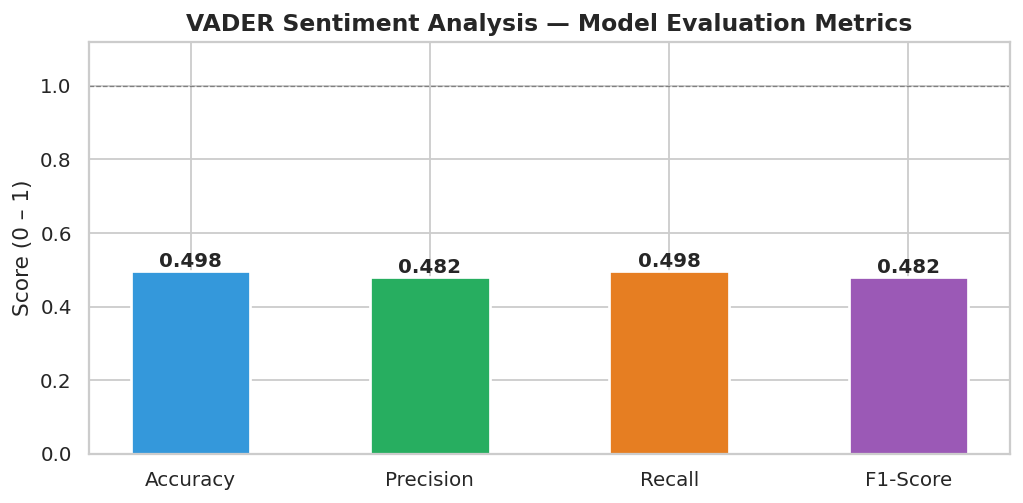

In [91]:
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
fig, ax = plt.subplots(figsize=(8, 4))

bar_cols = ['#3498db', '#27ae60', '#e67e22', '#9b59b6']
bars = ax.bar(metrics.keys(), metrics.values(), color=bar_cols,
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.12)
ax.set_title('VADER Sentiment Analysis — Model Evaluation Metrics')
ax.set_ylabel('Score (0 – 1)')
ax.axhline(1.0, color='gray', linewidth=0.7, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'model_evaluation_metrics.png'), bbox_inches='tight')
plt.show()

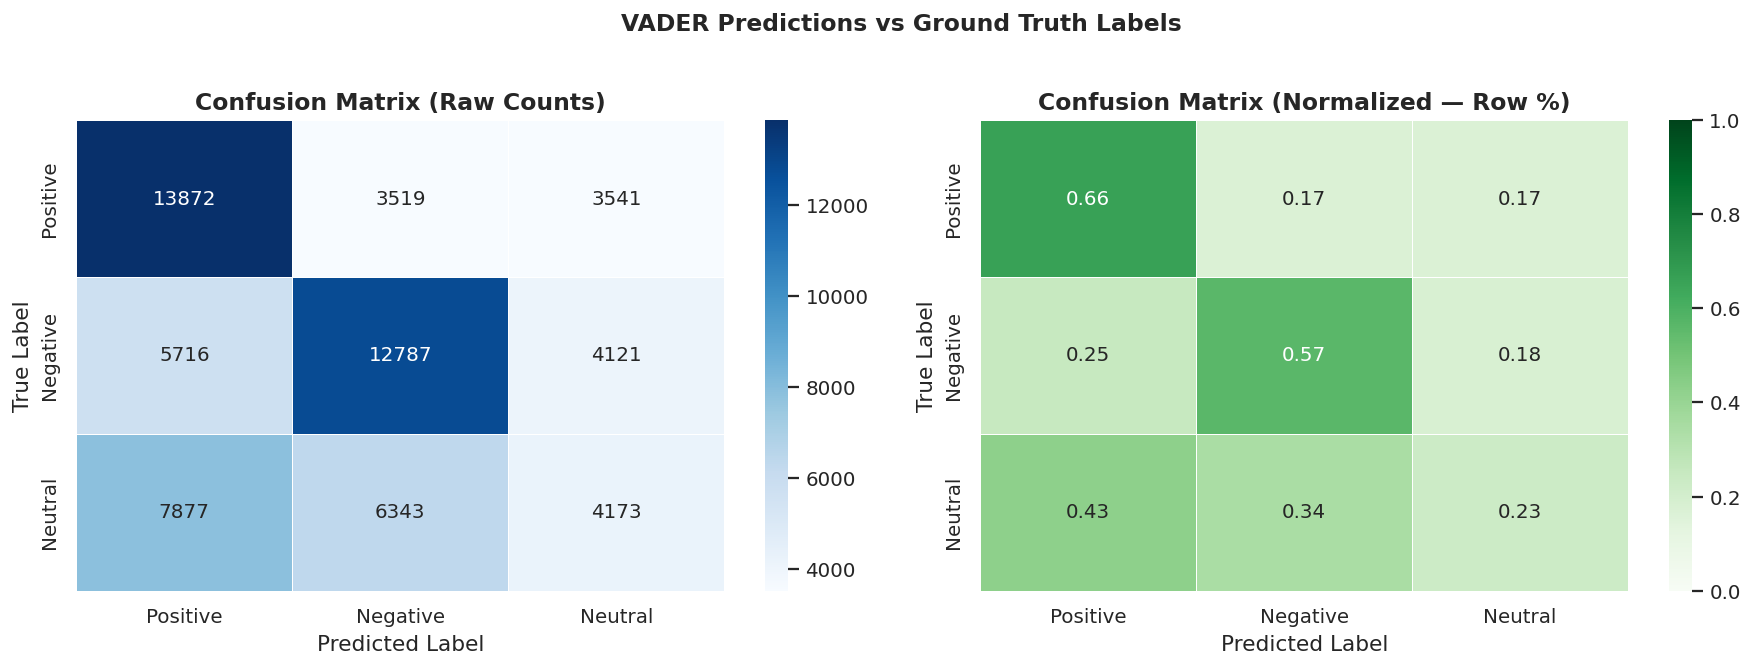


Reading tip:
  Diagonal cells = correct predictions (higher = better)
  Off-diagonal   = misclassifications


In [92]:
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white', ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized — Row %)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle('VADER Predictions vs Ground Truth Labels',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'confusion_matrix.png'), bbox_inches='tight')
plt.show()

print('\nReading tip:')
print('  Diagonal cells = correct predictions (higher = better)')
print('  Off-diagonal   = misclassifications')

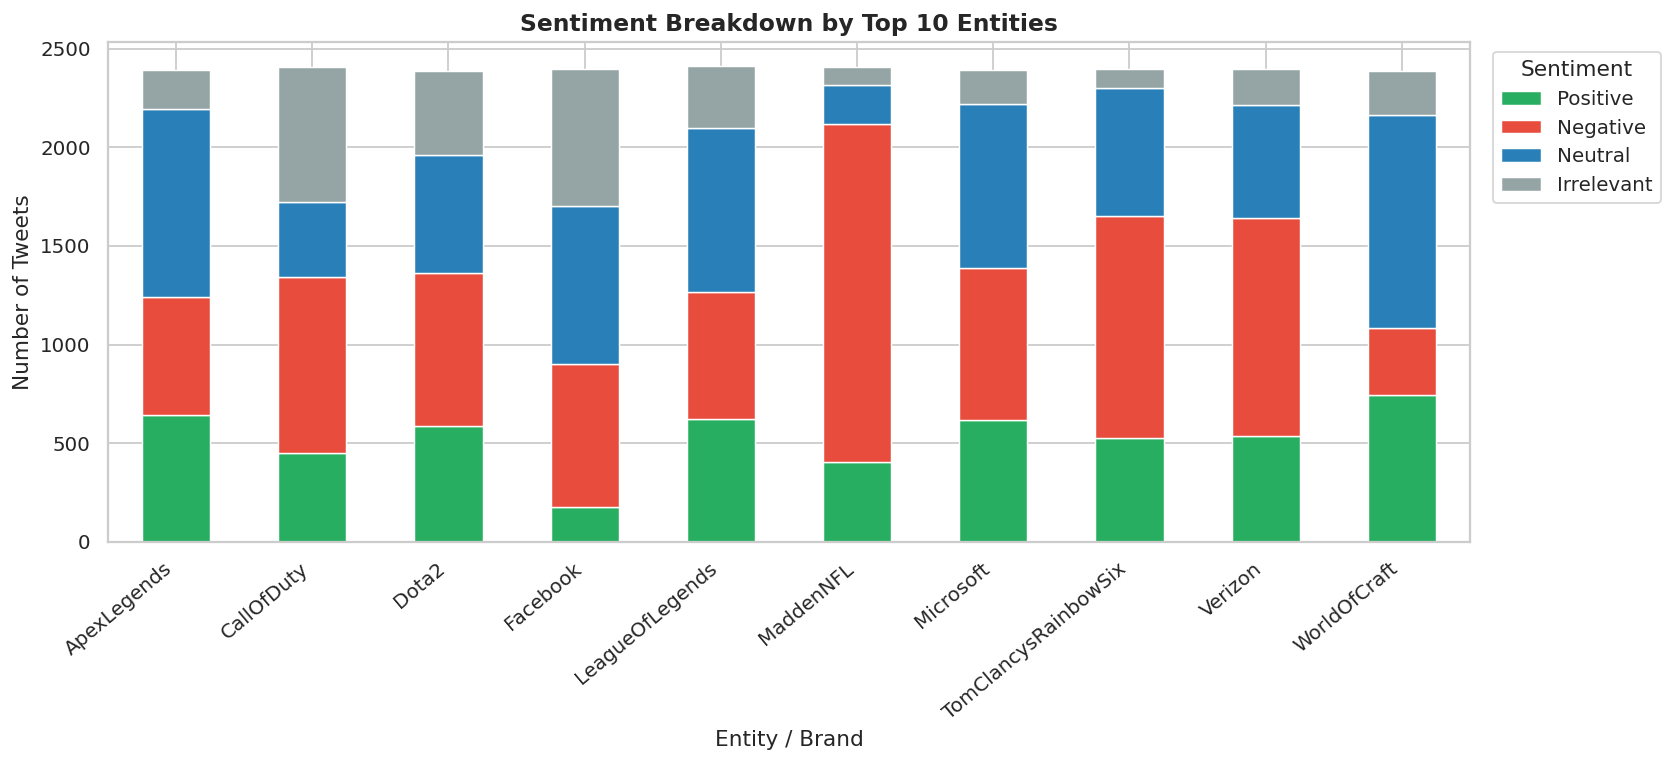

In [93]:
top_entities = df['Entity'].value_counts().head(10).index
df_top = df[df['Entity'].isin(top_entities)]

entity_sent = df_top.groupby(['Entity', 'Sentiment']).size().unstack(fill_value=0)
avail_cols  = [c for c in ['Positive','Negative','Neutral','Irrelevant'] if c in entity_sent.columns]
plot_colors = [COLORS[c] for c in avail_cols]

entity_sent[avail_cols].plot(
    kind='bar', stacked=True, color=plot_colors,
    figsize=(13, 6), edgecolor='white', linewidth=0.8
)
plt.title('Sentiment Breakdown by Top 10 Entities')
plt.xlabel('Entity / Brand')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=40, ha='right')
plt.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'entity_sentiment_breakdown.png'), bbox_inches='tight')
plt.show()

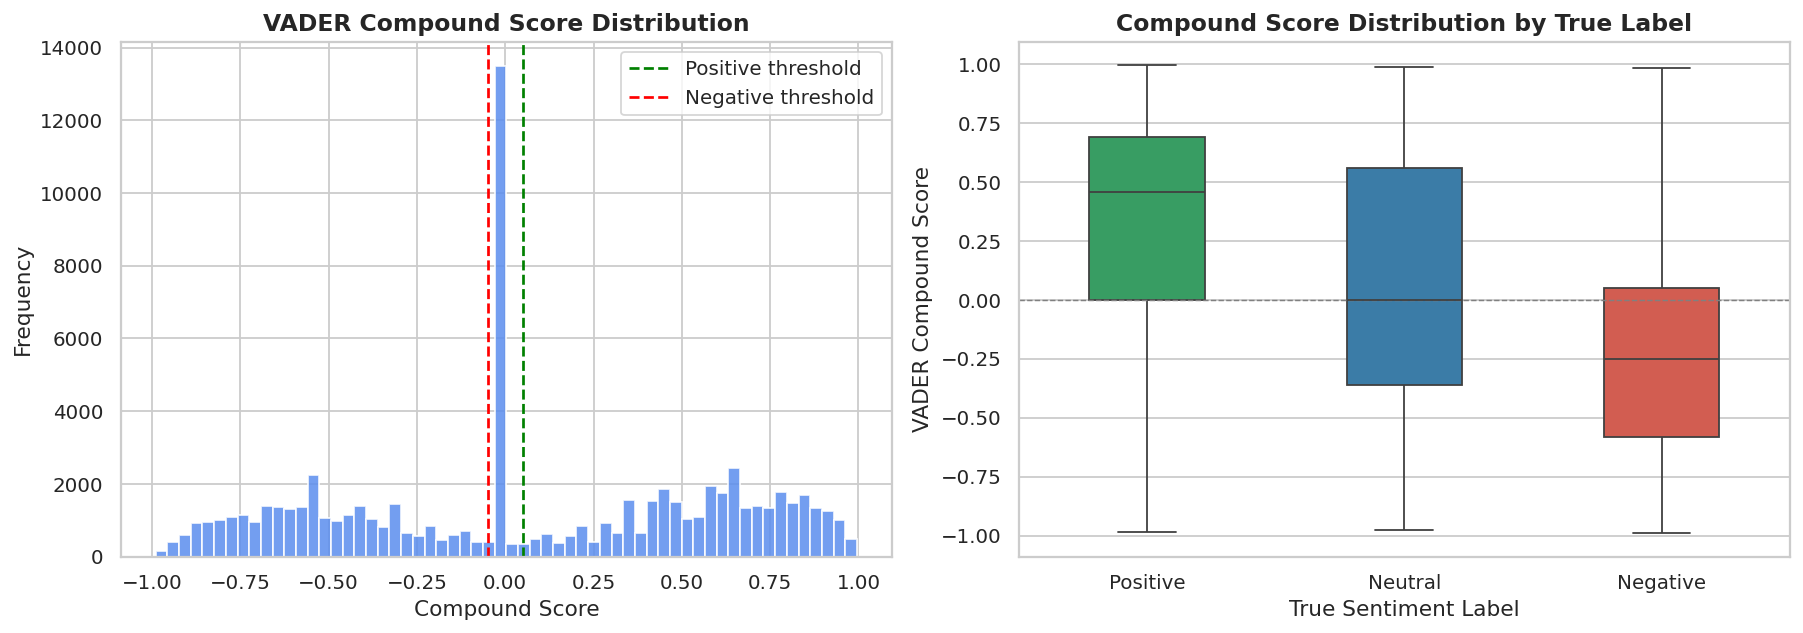

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['v_compound'], bins=60, color='#5b8dee', edgecolor='white', alpha=0.85)
axes[0].axvline( 0.05, color='green', linestyle='--', linewidth=1.5, label='Positive threshold')
axes[0].axvline(-0.05, color='red',   linestyle='--', linewidth=1.5, label='Negative threshold')
axes[0].set_title('VADER Compound Score Distribution')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

df_box = df[df['Sentiment'].isin(['Positive','Negative','Neutral'])]
sns.boxplot(data=df_box, x='Sentiment', y='v_compound',
            palette={'Positive':'#27ae60','Negative':'#e74c3c','Neutral':'#2980b9'},
            ax=axes[1], width=0.45)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Compound Score Distribution by True Label')
axes[1].set_xlabel('True Sentiment Label')
axes[1].set_ylabel('VADER Compound Score')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'vader_score_distribution.png'), bbox_inches='tight')
plt.show()

In [96]:
print('   TWITTER SENTIMENT ANALYSIS — KEY FINDINGS')

total = len(df)
print('\nSentiment Distribution:')
for s in df['Sentiment'].value_counts().index:
    c = (df['Sentiment'] == s).sum()
    print(f'   {s:<12}: {c:>6,} tweets ({c/total*100:.1f}%)')

print('\nVADER Model Metrics (vs ground truth):')
print(f'   Accuracy  : {acc*100:.2f}%')
print(f'   Precision : {prec:.4f}')
print(f'   Recall    : {rec:.4f}')
print(f'   F1-Score  : {f1:.4f}')

print('\nEntity Insights:')
print(f'   Most discussed  : {df["Entity"].value_counts().idxmax()}')
print(f'   Most positive   : {df[df["Sentiment"]=="Positive"]["Entity"].value_counts().idxmax()}')
print(f'   Most negative   : {df[df["Sentiment"]=="Negative"]["Entity"].value_counts().idxmax()}')

print('\nAverage VADER Compound Score by True Label:')
for s in df['Sentiment'].unique():
    if s in ['Positive', 'Negative', 'Neutral']:
        avg = df[df['Sentiment']==s]['v_compound'].mean()
        print(f'   {s:<12}: {avg:+.4f}')


print('Analysis Complete!')

   TWITTER SENTIMENT ANALYSIS — KEY FINDINGS

Sentiment Distribution:
   Negative    : 22,624 tweets (30.2%)
   Positive    : 20,932 tweets (27.9%)
   Neutral     : 18,393 tweets (24.5%)
   Irrelevant  : 13,047 tweets (17.4%)

VADER Model Metrics (vs ground truth):
   Accuracy  : 49.77%
   Precision : 0.4815
   Recall    : 0.4977
   F1-Score  : 0.4820

Entity Insights:
   Most discussed  : LeagueOfLegends
   Most positive   : AssassinsCreed
   Most negative   : MaddenNFL

Average VADER Compound Score by True Label:
   Positive    : +0.3255
   Neutral     : +0.0784
   Negative    : -0.1885
Analysis Complete!
